In [62]:
import numpy as numpy
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


In [63]:
df=pd.read_csv('UK_Accident.csv')

In [64]:
df.head()

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),Local_Authority_(Highway),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Control,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,04/01/2005,3,17:42,12,E09000020,3,3218,Single carriageway,30,NaN,-1,0,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,05/01/2005,4,17:36,12,E09000020,4,450,Dual carriageway,30,Automatic traffic signal,5,0,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,06/01/2005,5,00:15,12,E09000020,5,0,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,07/01/2005,6,10:35,12,E09000020,3,3220,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,10/01/2005,2,21:13,12,E09000020,6,0,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


In [65]:
df.isnull().sum().sum()

np.int64(3655911)

In [66]:
df.columns

Index(['Unnamed: 0', 'Accident_Index', 'Location_Easting_OSGR',
       'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force',
       'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties',
       'Date', 'Day_of_Week', 'Time', 'Local_Authority_(District)',
       'Local_Authority_(Highway)', '1st_Road_Class', '1st_Road_Number',
       'Road_Type', 'Speed_limit', 'Junction_Control', '2nd_Road_Class',
       '2nd_Road_Number', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions',
       'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'LSOA_of_Accident_Location', 'Year'],
      dtype='str')

In [67]:
df.drop([ 'Unnamed: 0',
    'Accident_Index',
    'Location_Easting_OSGR',
    'Location_Northing_OSGR',
    'LSOA_of_Accident_Location',
    'Local_Authority_(Highway)'],axis=1,inplace=True)

In [68]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Control,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year
0,-0.191170,51.489096,1,2,1,1,04/01/2005,3,17:42,12,3,3218,Single carriageway,30,NaN,-1,0,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,2005
1,-0.211708,51.520075,1,3,1,1,05/01/2005,4,17:36,12,4,450,Dual carriageway,30,Automatic traffic signal,5,0,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
2,-0.206458,51.525301,1,3,2,1,06/01/2005,5,00:15,12,5,0,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
3,-0.173862,51.482442,1,3,1,1,07/01/2005,6,10:35,12,3,3220,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,2005
4,-0.156618,51.495752,1,3,1,1,10/01/2005,2,21:13,12,6,0,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,2005


In [69]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

In [70]:
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Year'] = df['Date'].dt.year

In [71]:
df.drop(['Date', 'Time'], axis=1, inplace=True)

In [72]:
df['Carriageway_Hazards'].isnull().sum()

np.int64(1476900)

In [73]:
df.drop('Number_of_Casualties',axis=1,inplace=True)

In [74]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Control,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,30,NaN,-1,0,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,4
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,30,Automatic traffic signal,5,0,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,5
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,6
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,2005,1,7
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,30,NaN,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,2005,1,10


In [75]:
df['Road_Type'].value_counts()
df['Road_Type'].isnull().sum()


np.int64(0)

In [94]:
df.isnull().sum().sum()

np.int64(0)

In [95]:
df['Special_Conditions_at_Site']=df['Special_Conditions_at_Site'].fillna('None')
df['Carriageway_Hazards']=df['Carriageway_Hazards'].fillna('None')

In [96]:
df.isnull().sum()

Longitude                                                                              0
Latitude                                                                               0
Police_Force                                                                           0
Accident_Severity                                                                      0
Number_of_Vehicles                                                                     0
Day_of_Week                                                                            0
Local_Authority_(District)                                                             0
1st_Road_Class                                                                         0
1st_Road_Number                                                                        0
Road_Type                                                                              0
Speed_limit                                                                            0
Junction_Control     

In [97]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Control,2nd_Road_Class,2nd_Road_Number,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day,Pedestrian_Crossing-Human_Control_Control by other authorised person,Pedestrian_Crossing-Human_Control_Control by school crossing patrol,Pedestrian_Crossing-Human_Control_None within 50 metres,Pedestrian_Crossing-Physical_Facilities_Central refuge,Pedestrian_Crossing-Physical_Facilities_Footbridge or subway,Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters,Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction,Pedestrian_Crossing-Physical_Facilities_Zebra crossing,Pedestrian_Crossing-Physical_Facilities_non-junction pedestrian crossing
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,30,None,-1,0,Daylight: Street light present,Raining without high winds,Wet/Damp,None,None,1,Yes,2005,1,4,False,False,True,False,False,False,False,True,False
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,30,Automatic traffic signal,5,0,Darkness: Street lights present and lit,Fine without high winds,Dry,None,None,1,Yes,2005,1,5,False,False,True,False,False,False,True,False,False
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,30,None,-1,0,Darkness: Street lights present and lit,Fine without high winds,Dry,None,None,1,Yes,2005,1,6,False,False,True,False,False,True,False,False,False
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,30,None,-1,0,Daylight: Street light present,Fine without high winds,Dry,None,None,1,Yes,2005,1,7,False,False,True,False,False,True,False,False,False
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,30,None,-1,0,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,None,None,1,Yes,2005,1,10,False,False,True,False,False,True,False,False,False


In [80]:
df['Junction_Control'] = df['Junction_Control'].fillna('None')

In [81]:
df['Pedestrian_Crossing-Human_Control'].value_counts()



Pedestrian_Crossing-Human_Control
None within 50 metres                 1495269
Control by other authorised person       5220
Control by school crossing patrol        3644
Name: count, dtype: int64

In [82]:
df = pd.get_dummies(df, columns=['Pedestrian_Crossing-Human_Control'])

In [83]:
df['Pedestrian_Crossing-Physical_Facilities'].value_counts()


Pedestrian_Crossing-Physical_Facilities
No physical crossing within 50 meters          1252571
Pedestrian phase at traffic signal junction     100248
non-junction pedestrian crossing                 79231
Zebra crossing                                   40106
Central refuge                                   27660
Footbridge or subway                              4300
Name: count, dtype: int64

In [84]:
df = pd.get_dummies(df, columns=['Pedestrian_Crossing-Physical_Facilities'])

In [85]:
df['Light_Conditions'].value_counts()


Light_Conditions
Daylight: Street light present               1102222
Darkness: Street lights present and lit       296340
Darkeness: No street lighting                  82559
Darkness: Street lighting unknown              16120
Darkness: Street lights present but unlit       6909
Name: count, dtype: int64

In [86]:
df['Weather_Conditions'].value_counts()


Weather_Conditions
Fine without high winds       1203943
Raining without high winds     177663
Other                           33503
Unknown                         28422
Raining with high winds         20813
Fine with high winds            18355
Snowing without high winds      11301
Fog or mist                      8190
Snowing with high winds          1960
Name: count, dtype: int64

In [87]:
df['Road_Surface_Conditions'].value_counts()


Road_Surface_Conditions
Dry                          1034670
Wet/Damp                      423477
Frost/Ice                      31405
Snow                           10497
Flood (Over 3cm of water)       2143
Normal                          1958
Name: count, dtype: int64

In [88]:
df['Special_Conditions_at_Site'].value_counts()

Special_Conditions_at_Site
None                                               1467568
Roadworks                                            17223
Ol or diesel                                          5243
Mud                                                   4610
Road surface defective                                3664
Auto traffic singal out                               2788
Permanent sign or marking defective or obscured       2269
Auto traffic signal partly defective                   785
Name: count, dtype: int64

In [89]:
df.isnull().sum()

Longitude                                                                              101
Latitude                                                                                 0
Police_Force                                                                             0
Accident_Severity                                                                        0
Number_of_Vehicles                                                                       0
Day_of_Week                                                                              0
Local_Authority_(District)                                                               0
1st_Road_Class                                                                           0
1st_Road_Number                                                                          0
Road_Type                                                                                0
Speed_limit                                                                              0

In [90]:
df = df.dropna(subset=['Longitude'])

In [ ]:
df.isnull().sum()


Longitude                                      0
Latitude                                       0
Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Day_of_Week                                    0
Local_Authority_(District)                     0
1st_Road_Class                                 0
1st_Road_Number                                0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                               0
2nd_Road_Class                                 0
2nd_Road_Number                                0
Pedestrian_Crossing-Human_Control              0
Pedestrian_Crossing-Physical_Facilities        0
Light_Conditions                               0
Weather_Conditions                             0
Road_Surface_Conditions                        0
Special_Conditions_at_Site                     0
Carriageway_Hazards 

In [98]:
df['Light_Conditions'] = df['Light_Conditions'].replace({
    'Daylight: Street light present': 'Daylight',
    'Darkness: Street lights present and lit': 'Darkness_Lit',
    'Darkness: No street lighting': 'Darkness_No_Light',
    'Darkness: Street lighting unknown': 'Darkness_Unknown',
    'Darkness: Street lights present but unlit': 'Darkness_Unlit'
})

In [99]:
df = pd.get_dummies(df, columns=['Light_Conditions'])

In [100]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Road_Type,Speed_limit,Junction_Control,2nd_Road_Class,2nd_Road_Number,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day,Pedestrian_Crossing-Human_Control_Control by other authorised person,Pedestrian_Crossing-Human_Control_Control by school crossing patrol,Pedestrian_Crossing-Human_Control_None within 50 metres,Pedestrian_Crossing-Physical_Facilities_Central refuge,Pedestrian_Crossing-Physical_Facilities_Footbridge or subway,Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters,Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction,Pedestrian_Crossing-Physical_Facilities_Zebra crossing,Pedestrian_Crossing-Physical_Facilities_non-junction pedestrian crossing,Light_Conditions_Darkeness: No street lighting,Light_Conditions_Darkness_Lit,Light_Conditions_Darkness_Unknown,Light_Conditions_Darkness_Unlit,Light_Conditions_Daylight
0,-0.191170,51.489096,1,2,1,3,12,3,3218,Single carriageway,30,None,-1,0,Raining without high winds,Wet/Damp,None,None,1,Yes,2005,1,4,False,False,True,False,False,False,False,True,False,False,False,False,False,True
1,-0.211708,51.520075,1,3,1,4,12,4,450,Dual carriageway,30,Automatic traffic signal,5,0,Fine without high winds,Dry,None,None,1,Yes,2005,1,5,False,False,True,False,False,False,True,False,False,False,True,False,False,False
2,-0.206458,51.525301,1,3,2,5,12,5,0,Single carriageway,30,None,-1,0,Fine without high winds,Dry,None,None,1,Yes,2005,1,6,False,False,True,False,False,True,False,False,False,False,True,False,False,False
3,-0.173862,51.482442,1,3,1,6,12,3,3220,Single carriageway,30,None,-1,0,Fine without high winds,Dry,None,None,1,Yes,2005,1,7,False,False,True,False,False,True,False,False,False,False,False,False,False,True
4,-0.156618,51.495752,1,3,1,2,12,6,0,Single carriageway,30,None,-1,0,Fine without high winds,Wet/Damp,None,None,1,Yes,2005,1,10,False,False,True,False,False,True,False,False,False,False,False,True,False,False


In [107]:
df=pd.get_dummies(df,columns=['Junction_Control'])
df=pd.get_dummies(df,columns=['Weather_Conditions'])
df=pd.get_dummies(df,columns=['Road_Surface_Conditions'])

In [108]:
df.columns

Index(['Longitude', 'Latitude', 'Police_Force', 'Accident_Severity',
       'Number_of_Vehicles', 'Day_of_Week', 'Local_Authority_(District)',
       '1st_Road_Class', '1st_Road_Number', 'Speed_limit', '2nd_Road_Class',
       '2nd_Road_Number', 'Special_Conditions_at_Site', 'Carriageway_Hazards',
       'Urban_or_Rural_Area', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'Year', 'Month', 'Day',
       'Pedestrian_Crossing-Human_Control_Control by other authorised person',
       'Pedestrian_Crossing-Human_Control_Control by school crossing patrol',
       'Pedestrian_Crossing-Human_Control_None within 50 metres',
       'Pedestrian_Crossing-Physical_Facilities_Central refuge',
       'Pedestrian_Crossing-Physical_Facilities_Footbridge or subway',
       'Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters',
       'Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction',
       'Pedestrian_Crossing-Physical_Facilities_Zebr

In [109]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day,Pedestrian_Crossing-Human_Control_Control by other authorised person,Pedestrian_Crossing-Human_Control_Control by school crossing patrol,Pedestrian_Crossing-Human_Control_None within 50 metres,Pedestrian_Crossing-Physical_Facilities_Central refuge,Pedestrian_Crossing-Physical_Facilities_Footbridge or subway,Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters,Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction,Pedestrian_Crossing-Physical_Facilities_Zebra crossing,Pedestrian_Crossing-Physical_Facilities_non-junction pedestrian crossing,Light_Conditions_Darkeness: No street lighting,Light_Conditions_Darkness_Lit,Light_Conditions_Darkness_Unknown,Light_Conditions_Darkness_Unlit,Light_Conditions_Daylight,Road_Type_Dual carriageway,Road_Type_One way street,Road_Type_Roundabout,Road_Type_Single carriageway,Road_Type_Slip road,Road_Type_Unknown,Junction_Control_Authorised person,Junction_Control_Automatic traffic signal,Junction_Control_Giveway or uncontrolled,Junction_Control_None,Junction_Control_Stop Sign,Weather_Conditions_Fine with high winds,Weather_Conditions_Fine without high winds,Weather_Conditions_Fog or mist,Weather_Conditions_Other,Weather_Conditions_Raining with high winds,Weather_Conditions_Raining without high winds,Weather_Conditions_Snowing with high winds,Weather_Conditions_Snowing without high winds,Weather_Conditions_Unknown,Road_Surface_Conditions_Dry,Road_Surface_Conditions_Flood (Over 3cm of water),Road_Surface_Conditions_Frost/Ice,Road_Surface_Conditions_Normal,Road_Surface_Conditions_Snow,Road_Surface_Conditions_Wet/Damp
0,-0.191170,51.489096,1,2,1,3,12,3,3218,30,-1,0,None,None,1,Yes,2005,1,4,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,-0.211708,51.520075,1,3,1,4,12,4,450,30,5,0,None,None,1,Yes,2005,1,5,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
2,-0.206458,51.525301,1,3,2,5,12,5,0,30,-1,0,None,None,1,Yes,2005,1,6,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
3,-0.173862,51.482442,1,3,1,6,12,3,3220,30,-1,0,None,None,1,Yes,2005,1,7,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False
4,-0.156618,51.495752,1,3,1,2,12,6,0,30,-1,0,None,None,1,Yes,2005,1,10,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


In [111]:
df['Carriageway_Hazards'].value_counts()


Carriageway_Hazards
None                                       1476802
Other object in carriageway                  11760
Any animal (except a ridden horse)            8014
Pedestrian in carriageway (not injured)       3585
Involvement with previous accident            2282
Dislodged vehicle load in carriageway         1606
Name: count, dtype: int64

In [112]:
df=pd.get_dummies(df,columns=['Special_Conditions_at_Site'])
df=pd.get_dummies(df,columns=['Carriageway_Hazards'])

In [113]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day,Pedestrian_Crossing-Human_Control_Control by other authorised person,Pedestrian_Crossing-Human_Control_Control by school crossing patrol,Pedestrian_Crossing-Human_Control_None within 50 metres,Pedestrian_Crossing-Physical_Facilities_Central refuge,Pedestrian_Crossing-Physical_Facilities_Footbridge or subway,Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters,Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction,Pedestrian_Crossing-Physical_Facilities_Zebra crossing,Pedestrian_Crossing-Physical_Facilities_non-junction pedestrian crossing,Light_Conditions_Darkeness: No street lighting,Light_Conditions_Darkness_Lit,Light_Conditions_Darkness_Unknown,Light_Conditions_Darkness_Unlit,Light_Conditions_Daylight,Road_Type_Dual carriageway,Road_Type_One way street,Road_Type_Roundabout,Road_Type_Single carriageway,Road_Type_Slip road,Road_Type_Unknown,Junction_Control_Authorised person,Junction_Control_Automatic traffic signal,Junction_Control_Giveway or uncontrolled,Junction_Control_None,Junction_Control_Stop Sign,Weather_Conditions_Fine with high winds,Weather_Conditions_Fine without high winds,Weather_Conditions_Fog or mist,Weather_Conditions_Other,Weather_Conditions_Raining with high winds,Weather_Conditions_Raining without high winds,Weather_Conditions_Snowing with high winds,Weather_Conditions_Snowing without high winds,Weather_Conditions_Unknown,Road_Surface_Conditions_Dry,Road_Surface_Conditions_Flood (Over 3cm of water),Road_Surface_Conditions_Frost/Ice,Road_Surface_Conditions_Normal,Road_Surface_Conditions_Snow,Road_Surface_Conditions_Wet/Damp,Special_Conditions_at_Site_Auto traffic signal partly defective,Special_Conditions_at_Site_Auto traffic singal out,Special_Conditions_at_Site_Mud,Special_Conditions_at_Site_None,Special_Conditions_at_Site_Ol or diesel,Special_Conditions_at_Site_Permanent sign or marking defective or obscured,Special_Conditions_at_Site_Road surface defective,Special_Conditions_at_Site_Roadworks,Carriageway_Hazards_Any animal (except a ridden horse),Carriageway_Hazards_Dislodged vehicle load in carriageway,Carriageway_Hazards_Involvement with previous accident,Carriageway_Hazards_None,Carriageway_Hazards_Other object in carriageway,Carriageway_Hazards_Pedestrian in carriageway (not injured)
0,-0.191170,51.489096,1,2,1,3,12,3,3218,30,-1,0,1,Yes,2005,1,4,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False
1,-0.211708,51.520075,1,3,1,4,12,4,450,30,5,0,1,Yes,2005,1,5,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
2,-0.206458,51.525301,1,3,2,5,12,5,0,30,-1,0,1,Yes,2005,1,6,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
3,-0.173862,51.482442,1,3,1,6,12,3,3220,30,-1,0,1,Yes,2005,1,7,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,Fa

In [114]:
df['Accident_Severity'].value_counts()

Accident_Severity
3    1280120
2     204488
1      19441
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


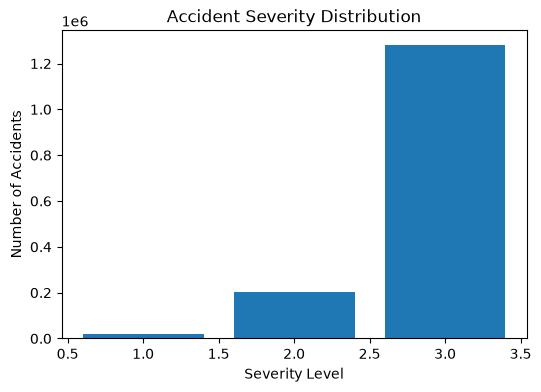

In [115]:
import matplotlib.pyplot as plt

severity_counts = df['Accident_Severity'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(severity_counts.index, severity_counts.values)

plt.title("Accident Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Accidents")

plt.show()

In [116]:
df[df.select_dtypes(include=['bool']).columns] = df.select_dtypes(include=['bool']).astype(int)

In [117]:
df.head()

,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year,Month,Day,Pedestrian_Crossing-Human_Control_Control by other authorised person,Pedestrian_Crossing-Human_Control_Control by school crossing patrol,Pedestrian_Crossing-Human_Control_None within 50 metres,Pedestrian_Crossing-Physical_Facilities_Central refuge,Pedestrian_Crossing-Physical_Facilities_Footbridge or subway,Pedestrian_Crossing-Physical_Facilities_No physical crossing within 50 meters,Pedestrian_Crossing-Physical_Facilities_Pedestrian phase at traffic signal junction,Pedestrian_Crossing-Physical_Facilities_Zebra crossing,Pedestrian_Crossing-Physical_Facilities_non-junction pedestrian crossing,Light_Conditions_Darkeness: No street lighting,Light_Conditions_Darkness_Lit,Light_Conditions_Darkness_Unknown,Light_Conditions_Darkness_Unlit,Light_Conditions_Daylight,Road_Type_Dual carriageway,Road_Type_One way street,Road_Type_Roundabout,Road_Type_Single carriageway,Road_Type_Slip road,Road_Type_Unknown,Junction_Control_Authorised person,Junction_Control_Automatic traffic signal,Junction_Control_Giveway or uncontrolled,Junction_Control_None,Junction_Control_Stop Sign,Weather_Conditions_Fine with high winds,Weather_Conditions_Fine without high winds,Weather_Conditions_Fog or mist,Weather_Conditions_Other,Weather_Conditions_Raining with high winds,Weather_Conditions_Raining without high winds,Weather_Conditions_Snowing with high winds,Weather_Conditions_Snowing without high winds,Weather_Conditions_Unknown,Road_Surface_Conditions_Dry,Road_Surface_Conditions_Flood (Over 3cm of water),Road_Surface_Conditions_Frost/Ice,Road_Surface_Conditions_Normal,Road_Surface_Conditions_Snow,Road_Surface_Conditions_Wet/Damp,Special_Conditions_at_Site_Auto traffic signal partly defective,Special_Conditions_at_Site_Auto traffic singal out,Special_Conditions_at_Site_Mud,Special_Conditions_at_Site_None,Special_Conditions_at_Site_Ol or diesel,Special_Conditions_at_Site_Permanent sign or marking defective or obscured,Special_Conditions_at_Site_Road surface defective,Special_Conditions_at_Site_Roadworks,Carriageway_Hazards_Any animal (except a ridden horse),Carriageway_Hazards_Dislodged vehicle load in carriageway,Carriageway_Hazards_Involvement with previous accident,Carriageway_Hazards_None,Carriageway_Hazards_Other object in carriageway,Carriageway_Hazards_Pedestrian in carriageway (not injured)
0,-0.191170,51.489096,1,2,1,3,12,3,3218,30,-1,0,1,Yes,2005,1,4,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1,-0.211708,51.520075,1,3,1,4,12,4,450,30,5,0,1,Yes,2005,1,5,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
2,-0.206458,51.525301,1,3,2,5,12,5,0,30,-1,0,1,Yes,2005,1,6,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
3,-0.173862,51.482442,1,3,1,6,12,3,3220,30,-1,0,1,Yes,2005,1,7,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
4,-0.156618,51.495752,1,3,1,2,12,6,0,30,-1,0,1,Yes,2005,1,10,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0


In [118]:
df['Did_Police_Officer_Attend_Scene_of_Accident'].value_counts()

Did_Police_Officer_Attend_Scene_of_Accident
Yes    1218803
No      285246
Name: count, dtype: int64

In [119]:
df['Did_Police_Officer_Attend_Scene_of_Accident'] = df['Did_Police_Officer_Attend_Scene_of_Accident'].map({'Yes': 1, 'No': 0})

In [121]:
X=df.drop(['Accident_Severity'],axis=1)
y=df['Accident_Severity']

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)


In [126]:
print(y_resampled.value_counts())

Accident_Severity
2    1280120
3    1280120
1    1280120
Name: count, dtype: int64


In [123]:
X_train,X_test,y_train,y_test=train_test_split(X_resampled,y_resampled,random_state=42,test_size=0.2)

In [127]:
dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [128]:
y_pred=dtc.predict(X_test)

In [129]:
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,f1_score

In [130]:
accuracy_score(y_test,y_pred)

0.8672338009978231

In [131]:
confusion_matrix(y_test,y_pred)

array([[248190,   4999,   2725],
       [ 11974, 210579,  33859],
       [  4977,  43440, 207329]])

In [134]:
LR=LogisticRegression()

In [135]:
LR.fit(X_train,y_train)

c:\Users\nic\Desktop\Road Accident Severity Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [136]:
y_pred1=LR.predict(X_test)

In [137]:
accuracy_score(y_test,y_pred1)

0.4680407565957358

In [139]:
confusion_matrix(y_test,y_pred1)

array([[148460,  56112,  51342],
       [ 80136,  82284,  93992],
       [ 60858,  66143, 128745]])